In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

import torch
import torch.nn as nn

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import warnings

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [ ]:
kv = 0.797  # -
rho = 1.263  # [rho] = g/cm^3
R = 8.314  # J/mol.K

# Scaling factors for the state variables (mu0, mu1, mu2, mu3, C), obtained from data generation step
y_scale = np.array([3.38087406e+05, 2.45658822e+03, 2.57740255e+01, 3.65173638e-01,
       4.97344188e-01])

relu = torch.nn.functional.relu

class PBM(nn.Module):

    def __init__(self):
        super().__init__()

        self.R = R
        self.rho = rho
        self.kv = kv
        self.y_scale = torch.tensor(y_scale, dtype=torch.float32).to(device)

        self.kb2 = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.alfa = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.beta = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.kg = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.Eag = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.gama_g = nn.Parameter(torch.tensor(1, dtype=torch.float32))

    def Ceq(self, T_K):
        return (
                -16.17
                + 1.765e-1 * T_K
                - 6.439e-4 * T_K ** 2
                + 7.915e-7 * T_K ** 3
                )

    def forward(self, t, x, T):
        mu0, mu1, mu2, mu3, C = x[...,0], x[...,1], x[...,2], x[...,3], x[...,4]
        mu0 = mu0 * self.y_scale[0]
        mu1 = mu1 * self.y_scale[1]
        mu2 = mu2 * self.y_scale[2]
        mu3 = mu3 * self.y_scale[3]
        C = C * self.y_scale[4]

        T_K = T + 273.15
        Ceq_val = self.Ceq(T_K)

        S = C/torch.clamp(Ceq_val, min=1e-16)
        ms = self.kv * self.rho * mu3 * 1e3
        B2 = torch.exp(self.kb2) * relu(S - 1.0).pow(torch.exp(self.alfa)) * ms.pow(torch.exp(self.beta))
        G = torch.exp(self.kg) * torch.exp(-(torch.exp(self.Eag) / (self.R * T_K))) * relu(C - Ceq_val).pow(torch.exp(self.gama_g))

        dmu0 = (B2)/self.y_scale[0]
        dmu1 = G * mu0/self.y_scale[1]
        dmu2 = 2 * G * mu1/self.y_scale[2]
        dmu3 = 3 * G * mu2/self.y_scale[3]
        dC = -3 * self.rho * self.kv * G * mu2/self.y_scale[4]

        return torch.stack([dmu0, dmu1, dmu2, dmu3, dC], dim=-1)

class PIRNN(nn.Module):
    def __init__(self, n_state=5, n_ctrl=1, hidden=64, layers=2, delta=1, dropout=0.2):
        super().__init__()
        self.n_state = n_state
        self.n_ctrl  = n_ctrl
        self.delta = delta
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(input_size=n_state+n_ctrl,
                            hidden_size=hidden,
                            num_layers=layers,
                            batch_first=True,
                            dropout=dropout if layers > 1 else 0)
        self.batch_norm = nn.BatchNorm1d(hidden)
        self.fc = nn.Linear(hidden, n_state)

        self.noise_scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, x0, T_seq):
        batch, N, _ = T_seq.shape
        x0 = x0.unsqueeze(1).expand(-1, N, -1)
        lstm_in = torch.cat([x0, T_seq], dim=-1)
        out, _ = self.lstm(lstm_in)
        
        out_reshaped = out.reshape(-1, out.shape[-1])
        out_norm = self.batch_norm(out_reshaped)
        out_norm = out_norm.reshape(out.shape)
        out_norm = self.dropout(out_norm)
        
        x_hat   = self.fc(out)
        return torch.nn.functional.softplus(x_hat)

model = PIRNN().to(device)
rhs = PBM().to(device)

In [3]:
train_data = np.load(f"../sweep_results/saved_data/train_data_noiseless.npz")
x0_train = train_data['x0_train']
T_data_train = train_data['T_data_train']
y_data_train = train_data['y_data_train']

In [ ]:
cases = ['0', '1e0', '1e2','1e4','1e10', '1e13']  # Different lambda values
exp_no = 1  # Index of the experiment to plot

all_case_pred_results = {}
for case in cases:
    all_runs_test_pred_list = []
    for run_num in range(5):
        try:
            state_dict = torch.load(f'../sweep_results/saved_models/best_val_downsamp_2_{case}_{run_num}.pth', map_location=torch.device('cpu'))
        except FileNotFoundError:
            print(f"Model file for case {case} and run {run_num} not found. Skipping.")
            continue
        model.load_state_dict(state_dict['10']['model_state'])  # Use 10 training runs case here
        model.eval()

        # PIRNN prediction
        with torch.no_grad():
            pred_test = model(torch.tensor(x0_train, dtype=torch.float32).to(device), torch.tensor(T_data_train, dtype=torch.float32).to(device))
        pred_test = pred_test.detach().cpu().numpy()

        all_runs_test_pred_list.append(pred_test[exp_no,:,:])
    
    # Compute mean and SEM across runs for the current case
    mean_test_pred = np.mean(all_runs_test_pred_list, axis = 0)
    sem_test_pred = np.std(all_runs_test_pred_list, axis = 0, ddof=1)/np.sqrt(len(all_runs_test_pred_list))

    all_case_pred_results[case] = {'mean_test_pred':mean_test_pred,'sem_test_pred':sem_test_pred}

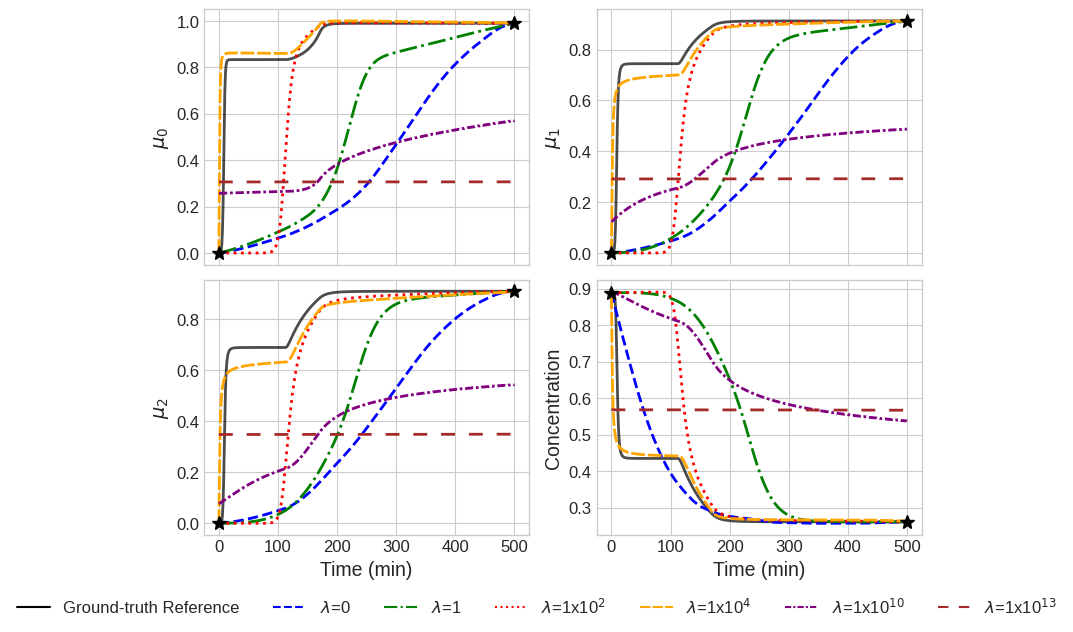

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(
    2, 2, 
    figsize=(8, 6),
    sharex=True, 
    tight_layout = True
)

colors = {'0': 'blue', '1e0': 'green', '1e2': 'red', '1e4': 'orange', '1e10': 'purple', '1e13': 'brown'}
linestyles = {
    '0': '--',                 # Dashed
    '1e0': '-.',               # Dash-dot
    '1e2': ':',                # Dotted
    '1e4': (0, (5, 1)),        # Densely dashed
    '1e10': (0, (3, 1, 1, 1)), # Dash-dot-dot
    '1e13': (0, (5, 5))        # Loosely dashed
}
case_labels = {'0': r'$\lambda$=0$', '1e0': r'$\lambda$=1$', '1e2': r'$\lambda$=1x10$^{2}$',
               '1e4': r'$\lambda$=1x10$^{4}$', '1e10': r'$\lambda$=1x10$^{10}$', '1e13': r'$\lambda$=1x10$^{13}$'}
cases_to_plot = ['0', '1e0', '1e2', '1e4', '1e10', '1e13']
var_to_plot = [r'$\mu_0$', r'$\mu_1$', r'$\mu_2$', 'Concentration']

noiseless_gt = y_data_train[exp_no,:,:]
time_steps = np.arange(len(noiseless_gt))

for i, j in enumerate([0,1,2,4]):
    
    # Plot noiseless ground truth reference
    axes[i//2,i%2].plot(time_steps, noiseless_gt[:,j], color='black', linestyle='-', linewidth = 2, alpha = 0.7)
    for case_id in cases_to_plot:
        
        results_data = all_case_pred_results[case_id]['mean_test_pred']
        sem_pred = all_case_pred_results[case_id]['sem_test_pred']
        color = colors.get(case_id)
        l_style = linestyles.get(case_id)
        
        # Plot mean prediction
        axes[i//2,i%2].plot(time_steps, results_data[:,j], color=color,linestyle=l_style,linewidth = 2)

    axes[i//2,i%2].set_ylabel(var_to_plot[i], fontsize=14)
    axes[i//2,i%2].tick_params(axis='both', which='major', labelsize=12)
    if i//2 == 1:
        axes[i//2,i%2].set_xlabel('Time (min)', fontsize=14)

    # Plot training boundary points
    axes[i//2,i%2].plot([0,500],noiseless_gt[[0,500],j],'*', markersize = 10, color = 'black')

legend_handles = [
    mlines.Line2D([], [], color='black', linestyle='-', label='Ground-truth Reference'),
    mlines.Line2D([], [], color='blue', linestyle='--', label=r'$\lambda$=0'),
    mlines.Line2D([], [], color='green', linestyle='-.', label=r'$\lambda$=1'),
    mlines.Line2D([], [], color='red', linestyle=':', label=r'$\lambda$=1x10$^{2}$'),
    mlines.Line2D([], [], color='orange', linestyle= (0, (5, 1)), label=r'$\lambda$=1x10$^{4}$'),
    mlines.Line2D([], [], color='purple', linestyle=(0, (3, 1, 1, 1)), label=r'$\lambda$=1x10$^{10}$'),
    mlines.Line2D([], [], color='brown', linestyle=(0, (5, 5)), label=r'$\lambda$=1x10$^{13}$')
]

fig.legend(handles=legend_handles, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), 
           ncol=7, 
           fontsize=12)

# plt.savefig("./downsamp_2_lambda.svg", bbox_inches = 'tight')
# plt.savefig("./downsamp_2_lambda.png", bbox_inches = 'tight')
# plt.savefig("./downsamp_2_lambda.pdf", bbox_inches = 'tight')

In [8]:
def lossX(pred, target, downsample=500):
    pred_downsample = pred[:, ::downsample, :]
    target_downsample = target[:, ::downsample, :] 
    
    mse = nn.MSELoss()(pred_downsample, target_downsample)
    return mse  # use MSE for evaluation

def lossG(pred, T_seq, rhs, dt):
    dx = (pred[:, 2:] - pred[:, :-2]) / (2*dt)
    x_mid = pred[:, 1:-1]
    T_mid = T_seq[:, 1:-1, 0]
    rhs_vals = rhs(None, x_mid, T_mid)
    return nn.MSELoss()(dx, rhs_vals)

In [ ]:
cases = ['0', '1e0', '1e2','1e4','1e6','1e8','1e10','1e13']
cases_lambda = {'0':0, '1e0':1e0, '1e2':1e2,'1e4':1e4,'1e6':1e6,'1e8':1e8,'1e10':1e10,'1e13':1e13}

all_case_loss = {}
for case in cases:
    all_runs_lX_list = []
    all_runs_lG_list = []
    for run_num in range(5):
        try:
            state_dict = torch.load(f'../sweep_results/saved_models/best_val_downsamp_2_{case}_{run_num}.pth', map_location=torch.device('cpu'))
        except FileNotFoundError:
            continue
        # Get the model and learned PBM parameters from the best validation model
        model.load_state_dict(state_dict['10']['model_state'])
        rhs.load_state_dict(state_dict['10']['rhs_state'])
        model.eval()
        with torch.no_grad():
            pred_test = model(torch.tensor(x0_train, dtype=torch.float32).to(device), torch.tensor(T_data_train, dtype=torch.float32).to(device))
            lX = lossX(pred_test, torch.tensor(y_data_train).to(device)).detach().cpu().numpy()
            lG = lossG(pred_test, torch.tensor(T_data_train, dtype=torch.float32).to(device), rhs, model.delta).detach().cpu().numpy() * cases_lambda[case]

        all_runs_lX_list.append(lX)
        all_runs_lG_list.append(lG)
        
    mean_lX = np.mean(all_runs_lX_list, axis = 0)
    sem_lX = np.std(all_runs_lX_list, axis = 0, ddof=1)/np.sqrt(len(all_runs_lX_list))

    mean_lG = np.mean(all_runs_lG_list, axis = 0)
    sem_lG = np.std(all_runs_lG_list, axis = 0, ddof=1)/np.sqrt(len(all_runs_lG_list))

    all_case_loss[case] = {'mean_lX':mean_lX,'sem_lX':sem_lX,
                           'mean_lG':mean_lG,'sem_lG':sem_lG}

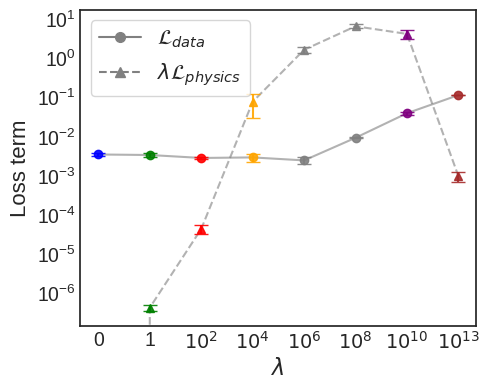

In [ ]:
plt.style.use('seaborn-v0_8-white')
fig, ax1 = plt.subplots(figsize=(5,4), tight_layout=True)

results_lX = np.array([all_case_loss[k]['mean_lX'] for k in all_case_loss.keys()])
sem_lX = np.array([all_case_loss[k]['sem_lX'] for k in all_case_loss.keys()])

results_lG = np.array([all_case_loss[k]['mean_lG'] for k in all_case_loss.keys()])
sem_lG = np.array([all_case_loss[k]['sem_lG'] for k in all_case_loss.keys()])

x_positions = np.arange(len(cases))
ax1.plot(x_positions, results_lX, linewidth=1.5, color='gray', linestyle='-', alpha=0.6)
ax1.plot(x_positions, results_lG, linewidth=1.5, color='gray', linestyle='--', alpha=0.6)

lambda_colors = ['blue', 'green', 'red', 'orange', 'gray', 'gray', 'purple', 'brown']

# Use color for the plotted points and error bars
for i in range(len(cases)):
    ax1.errorbar(i, results_lX[i], yerr=sem_lX[i],
                 color=lambda_colors[i], linestyle='none', marker='o', markersize=6,
                 capsize=5, alpha=0.9, elinewidth=1.5)
    
    ax1.errorbar(i, results_lG[i], yerr=sem_lG[i],
                 color=lambda_colors[i], linestyle='none', marker='^', markersize=6,
                 capsize=5, alpha=0.9, elinewidth=1.5)

ax1.set_ylabel('Loss term', fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(['0', '1', '$10^{2}$', '$10^{4}$', '$10^{6}$', '$10^{8}$', '$10^{10}$', '$10^{13}$'])
ax1.set_xlabel(r'$\lambda$', fontsize=16)
ax1.set_yscale('log')

legend_elements = [
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markersize=7, 
           markerfacecolor='gray', markeredgecolor='gray', label=r'$\mathcal{L}_{data}$'),
    Line2D([0], [0], color='gray', linestyle='--', marker='^', markersize=7, 
           markerfacecolor='gray', markeredgecolor='gray', label=r'$\lambda \mathcal{L}_{physics}$')
]
ax1.legend(handles=legend_elements, fontsize=15, frameon=True)

# plt.savefig("./downsamp_2_loss_log.svg", bbox_inches = 'tight')
# plt.savefig("./downsamp_2_loss_log.png", bbox_inches = 'tight')
# plt.savefig("./downsamp_2_loss_log.pdf", bbox_inches = 'tight')

## Pred

In [ ]:
kv = 0.797  # -
rho = 1.263  # [rho] = g/cm^3
R = 8.314  # J/mol.K

def odefun_pred(t, x, T_func, params):
    mu0, mu1, mu2, mu3, conc = x
    kb2, alfa, beta, kg, Eag, gama_g = np.exp(params)

    ms = kv * rho * mu3 * 1e3

    T = T_func(t)

    T_K = T + 273.15 
    Ceq = (
        -16.17
        + 1.765e-1 * T_K
        - 6.439e-4 * T_K ** 2
        + 7.915e-7 * T_K ** 3
    )  # g/g

    S = conc / Ceq

    B2 = kb2 * (max(S - 1, 0) ** alfa) * (ms ** beta)

    G = kg * np.exp(-Eag / (R * T_K)) * max(conc - Ceq, 0) ** gama_g

    dmi0dt = B2
    dmi1dt = G * mu0
    dmi2dt = 2 * G * mu1
    dmi3dt = 3 * G * mu2
    dcdt = -3 * rho * kv * G * mu2

    return [dmi0dt, dmi1dt, dmi2dt, dmi3dt, dcdt]

In [105]:
train_data = np.load(f"./train_noiseless.npz")
x0_train = train_data['x0_train']
T_data_train = train_data['T_data_train']
y_data_train = train_data['y_data_train']

In [ ]:
cases = ['3','5','9']  # Number of data points used for training
exp_no = 1             # Index of the experiment to plot

time_eval = np.arange(501).flatten()
time_span = (time_eval[0], time_eval[-1])
y0 = x0_train[exp_no]* y_scale
T_profile = T_data_train[exp_no].flatten()
T_func = interp1d(time_eval, T_profile, kind='linear', fill_value="extrapolate")

rhs_param_names = ['kb2', 'alfa', 'beta', 'kg', 'Eag', 'gama_g']

all_case_pred_results = {}
for case in cases:
    all_runs_test_pred_list = []
    all_runs_odes_pred_list = []
    for run_num in range(5):
        try:
            state_dict = torch.load(f'../sweep_results/saved_models/best_val_downsamp_{case}_{run_num}.pth')
        except FileNotFoundError:
            continue
        model.load_state_dict(state_dict['10']['model_state'])
        params = np.array([state_dict['10']['rhs_state'][param_name].item() for param_name in rhs_param_names])
        model.eval()
        # PIRNN prediction
        with torch.no_grad():
            pred_test = model(torch.tensor(x0_train, dtype=torch.float32).to(device), torch.tensor(T_data_train, dtype=torch.float32).to(device))
        pred_test = pred_test.detach().cpu().numpy()

        # ODE reevaluation
        with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                warnings.simplefilter("ignore", UserWarning)
                sol = solve_ivp(
                    fun=odefun_pred,
                    t_span=time_span,
                    y0=y0,
                    t_eval=time_eval,
                    args=(T_func, params),
                    method='LSODA'
                )
                pred_ode = (sol.y.T / y_scale).T

        all_runs_test_pred_list.append(pred_test[exp_no,:,:])
        all_runs_odes_pred_list.append(pred_ode[:,:])
        
    mean_test_pred = np.mean(all_runs_test_pred_list, axis = 0)
    sem_test_pred = np.std(all_runs_test_pred_list, axis = 0, ddof=1)/np.sqrt(len(all_runs_test_pred_list))

    mean_ode_pred = np.mean(all_runs_odes_pred_list, axis = 0)
    sem_ode_pred = np.std(all_runs_odes_pred_list, axis = 0, ddof=1)/np.sqrt(len(all_runs_odes_pred_list))

    all_case_pred_results[case] = {'mean_test_pred':mean_test_pred,'sem_test_pred':sem_test_pred,
                                   'mean_ode_pred':mean_ode_pred,'sem_ode_pred':sem_ode_pred}

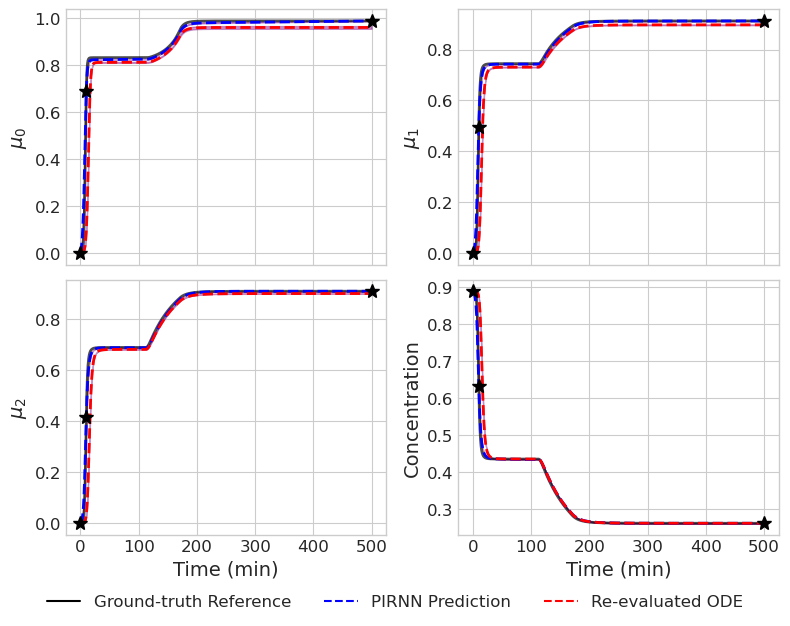

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(
    2, 2, 
    figsize=(8, 6),
    sharex=True, 
    tight_layout = True
)

var_to_plot = [r'$\mu_0$', r'$\mu_1$', r'$\mu_2$', 'Concentration']

case_id = '3' # Change to plot different cases

case_points = {'3':[0,10,500],'5':[0,10,100,300,500],'9':[0,5,10,20,50,100,200,300,500]}  # Sampling locations for each case

noiseless_gt = y_data_train[exp_no,:,:]
time_steps = np.arange(len(noiseless_gt))

for i, j in enumerate([0,1,2,4]): # Skip mu3 for plotting
    
    axes[i//2,i%2].plot(time_steps, noiseless_gt[:,j], color='black', linestyle='-', linewidth = 2, alpha = 0.7)
        
    results_data = all_case_pred_results[case_id]['mean_test_pred']
    sem_pred = all_case_pred_results[case_id]['sem_test_pred']
    
    # Plot mean PIRNN prediction with confidence interval
    axes[i//2,i%2].plot(time_steps, results_data[:,j], color='blue', linestyle='--',linewidth = 2)
    lower_bound = results_data - 1.96 * sem_pred
    upper_bound = results_data + 1.96 * sem_pred
    axes[i//2,i%2].fill_between(time_steps, lower_bound[:,j], upper_bound[:,j], color='blue', alpha=0.4)

    results_ode = all_case_pred_results[case_id]['mean_ode_pred']
    sem_ode = all_case_pred_results[case_id]['sem_ode_pred']
    
    # Plot mean ODE reevaluation prediction with confidence interval
    axes[i//2,i%2].plot(time_steps, results_ode[j,:], color='red', linestyle='--',linewidth = 2)
    lower_bound = results_ode - 1.96 * sem_ode
    upper_bound = results_ode + 1.96 * sem_ode
    axes[i//2,i%2].fill_between(time_steps, lower_bound[j,:], upper_bound[j,:], color='red', alpha=0.4)

    axes[i//2,i%2].set_ylabel(var_to_plot[i], fontsize=14)
    axes[i//2,i%2].tick_params(axis='both', which='major', labelsize=12)
    if i//2 == 1:
        axes[i//2,i%2].set_xlabel('Time (min)', fontsize=14)

    axes[i//2,i%2].plot(case_points[case_id],noiseless_gt[case_points[case_id],j],'*', markersize = 10, color = 'black')


legend_handles = [
    mlines.Line2D([], [], color='black', linestyle='-', label='Ground-truth Reference'),
    mlines.Line2D([], [], color='blue', linestyle='--', label='PIRNN Prediction'),
    mlines.Line2D([], [], color='red', linestyle='--', label='Re-evaluated ODE'),
]

fig.legend(handles=legend_handles, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), 
           ncol=3, 
           fontsize=12)

# plt.savefig("./downsamp_3_pred.svg", bbox_inches = 'tight')
# plt.savefig("./downsamp_3_pred.png", bbox_inches = 'tight')
# plt.savefig("./downsamp_3_pred.pdf", bbox_inches = 'tight')